<a href="https://colab.research.google.com/github/Mandip-xd/5CS037/blob/main/2548193_MandipGautam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Basic Data Exploration & Trend Visualization**

# 3.1 Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)





Importing tool & Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hdi_data = pd.read_csv('/content/Human_Development_Index_Dataset.csv', encoding='latin1')
hdi_data['year'] = pd.to_numeric(hdi_data['year'], errors='coerce')

Task-1. Extract Latest Year:

In [3]:
print("Available Unique Years:", hdi_data['year'].unique())

hdi_yr22 = hdi_data[hdi_data['year'] == 2022].copy()


Available Unique Years: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]


Task-2. Data Exploration

In [4]:
print(hdi_yr22.head(10))
print("Shape:", hdi_yr22.shape)
print(hdi_yr22.dtypes)


     Unnamed: 0 iso3              country  year    hdi  life_expectancy  \
32           33  AFG          Afghanistan  2022  0.462           62.879   
65           66  ALB              Albania  2022  0.789           76.833   
98           99  DZA              Algeria  2022  0.745           77.129   
131         132  AND              Andorra  2022  0.884           83.552   
164         165  AGO               Angola  2022  0.591           61.929   
197         198  ATG  Antigua and Barbuda  2022  0.826           79.236   
230         231  ARG            Argentina  2022  0.849           76.064   
263         264  ARM              Armenia  2022  0.786           73.372   
296         297  AUS            Australia  2022  0.946           83.579   
329         330  AUT              Austria  2022  0.926           82.412   

     pop_millions     hdi_f     hdi_m  life_expec_f  ...  gender_development  \
32      41.128771  0.332443  0.534145        66.213  ...               0.622   
65       2.842

Task-3. Missing Values & Cleaning Data

In [5]:
hdi_yr22 = hdi_yr22.replace("–", np.nan)

hdi_yr22['hdi'] = pd.to_numeric(hdi_yr22['hdi'], errors='coerce')
hdi_yr22['gross_inc_percap'] = pd.to_numeric(
    hdi_yr22['gross_inc_percap'], errors='coerce'
)

hdi_yr22.drop_duplicates(inplace=True)
hdi_yr22['hdi'] = hdi_yr22['hdi'].fillna(hdi_yr22['hdi'].median())

Task-4:Basic Statistics

In [6]:
avg_hdi = hdi_yr22['hdi'].mean()
med_hdi = hdi_yr22['hdi'].median()
std_hdi = hdi_yr22['hdi'].std()

top_country = hdi_yr22.loc[hdi_yr22['hdi'].idxmax(), 'country']
low_country = hdi_yr22.loc[hdi_yr22['hdi'].idxmin(), 'country']

print(avg_hdi, med_hdi, std_hdi)
print(top_country, low_country)


0.7230485436893206 0.7395 0.15228924684686668
Switzerland Somalia


Task-5. Filtering and Sorting

In [7]:
top_income = (
    hdi_yr22[hdi_yr22['hdi'] > 0.8]
    .sort_values(by='gross_inc_percap', ascending=False)
    .head(10)
)

print(top_income[['country', 'hdi', 'gross_inc_percap']])


                     country    hdi  gross_inc_percap
3332           Liechtenstein  0.942      146673.24150
4718                   Qatar  0.875       95944.37754
5213               Singapore  0.949       88761.14559
2705                 Ireland  0.950       87467.51391
3398              Luxembourg  0.927       78554.23640
6104    United Arab Emirates  0.937       74103.71494
5609             Switzerland  0.967       69432.78669
4322                  Norway  0.966       69189.76165
6170           United States  0.927       65564.93798
2474  Hong Kong, China (SAR)  0.956       62485.50516


Task 6: Adding HDI Category Column

In [8]:
def hdi_level(val):
    if val < 0.55:
        return "Low"
    elif val < 0.70:
        return "Medium"
    elif val < 0.80:
        return "High"
    else:
        return "Very High"

hdi_yr22['HDI_Level'] = hdi_yr22['hdi'].apply(hdi_level)
hdi_yr22.to_csv("HDI_2022_Classified.csv", index=False)


# 3.2 Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)


Task-1.Data Extraction and Saving

In [9]:
trend_df = hdi_data[hdi_data['year'].isin([2020, 2021, 2022])].copy()
trend_df = trend_df.replace("–", np.nan)

trend_df['hdi'] = pd.to_numeric(trend_df['hdi'], errors='coerce')
trend_df.dropna(subset=['hdi', 'country'], inplace=True)

trend_df.to_csv("HDI_Trend_2020_2022.csv", index=False)


Task-2.Data Cleaning

In [10]:
essential_cols = ['hdi', 'country', 'year']
print("Missing values in essential columns:")
print(hdi_yr22[essential_cols].isnull().sum())




Missing values in essential columns:
hdi        0
country    0
year       0
dtype: int64


In [11]:
hdi_2022_df = hdi_yr22.replace("–", np.nan)
hdi_2022_df['hdi'] = pd.to_numeric(hdi_2022_df['hdi'], errors='coerce')
hdi_2022_df['year'] = pd.to_numeric(hdi_2022_df['year'], errors='coerce')


In [12]:
hdi_2022_df.dropna(subset=['country', 'year'], inplace=True)
hdi_2022_df['hdi'] = hdi_2022_df['hdi'].fillna(hdi_2022_df['hdi'].median())


In [13]:
hdi_2022_df['country'] = (
    hdi_2022_df['country']
    .str.strip()
    .str.title()
)


In [14]:
before = hdi_2022_df.shape[0]
hdi_2022_df.drop_duplicates(inplace=True)
after = hdi_2022_df.shape[0]

print(f"Duplicates removed: {before - after}")


Duplicates removed: 0


In [15]:
print("Remaining missing values:")
print(hdi_2022_df[essential_cols].isnull().sum())

print("Final dataset shape:", hdi_2022_df.shape)


Remaining missing values:
hdi        0
country    0
year       0
dtype: int64
Final dataset shape: (206, 31)


Task-3.Visualization Tasks

*- Line Chart (Country-Level)*

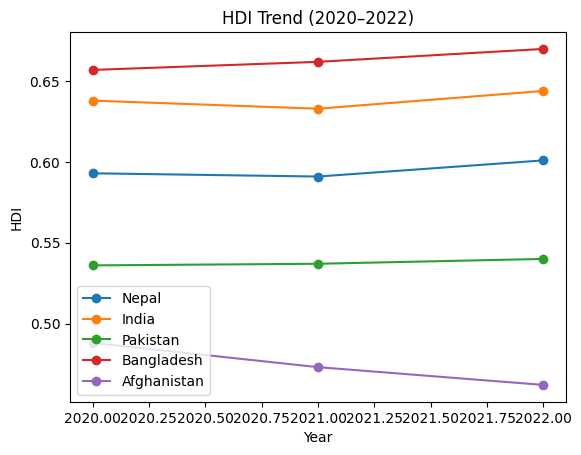

In [16]:
countries_demo = ["Nepal", "India", "Pakistan", "Bangladesh", "Afghanistan"]

plt.figure()
for c in countries_demo:
    temp = trend_df[trend_df['country'] == c]
    plt.plot(temp['year'], temp['hdi'], marker='o', label=c)

plt.title("HDI Trend (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.legend()
plt.show()


From 2020 to 2022, the line graph displays a generally stable or marginally rising trend in HDI values for all of the chosen nations. Around 2021, there is a slight stagnation that is probably caused by the COVID-19 pandemic. By 2022, the majority of nations exhibit signs of recovery, with human development indicators gradually improving.

B. Generate Visualizations


*– Bar Chart: Average HDI by Region (2020–2022)*

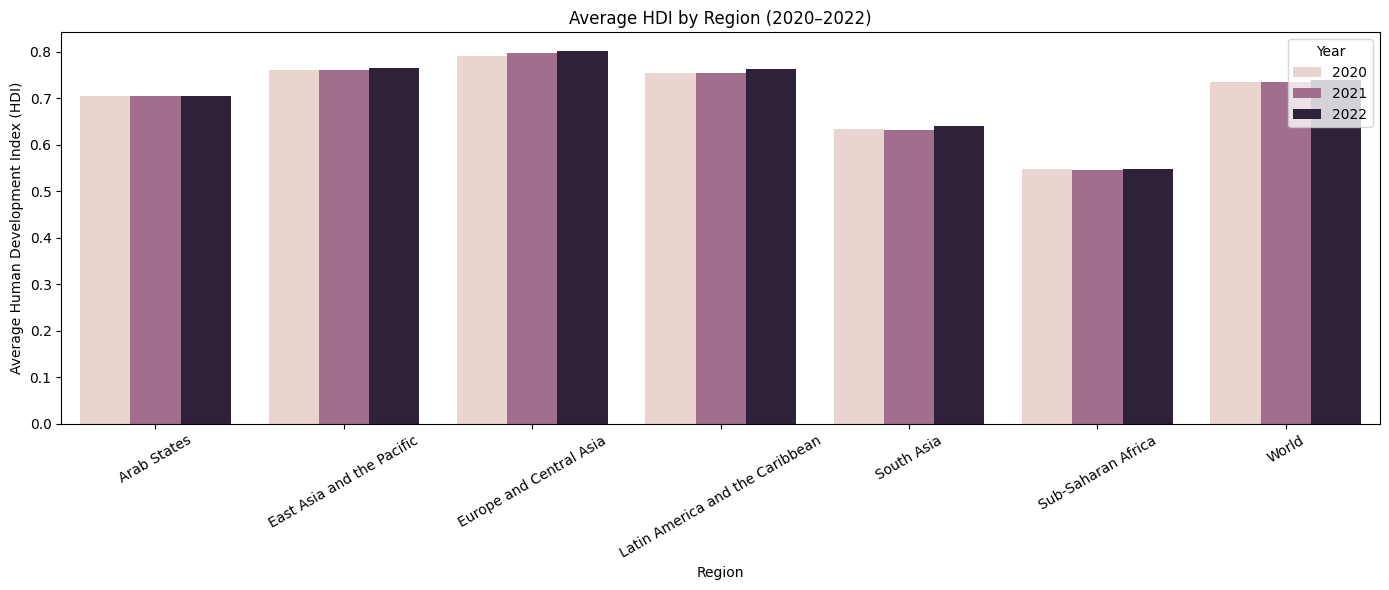

In [17]:
regions = [
    'Arab States',
    'East Asia and the Pacific',
    'Europe and Central Asia',
    'Latin America and the Caribbean',
    'South Asia',
    'Sub-Saharan Africa',
    'World'
]

hdi_region_df = hdi_data[
    hdi_data['country'].isin(regions) & hdi_data['year'].isin([2020, 2021, 2022])
].copy()

hdi_region_df = hdi_region_df.replace("–", np.nan)
hdi_region_df['hdi'] = pd.to_numeric(hdi_region_df['hdi'], errors='coerce')
hdi_region_df.dropna(subset=['hdi', 'country'], inplace=True)

avg_hdi_region = (
    hdi_region_df
    .groupby(['country', 'year'])['hdi']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=avg_hdi_region,
    x='country',
    y='hdi',
    hue='year'
)
plt.title("Average HDI by Region (2020–2022)")
plt.xlabel("Region")
plt.ylabel("Average Human Development Index (HDI)")
plt.legend(title="Year")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The bar graph clearly illustrates how the average HDI varies by location. Over the course of the three years, developed regions have consistently recorded higher HDI values than emerging regions. Most locations show a little increase trend between 2020 and 2022, suggesting a slow recovery from the COVID-19 pandemic. Europe and North America continue to be the highest, while Sub-Saharan Africa continues to be the lowest. There are no noticeable year-to-year variations.

*– Box Plot: HDI Distribution for 2020, 2021, and 2022*

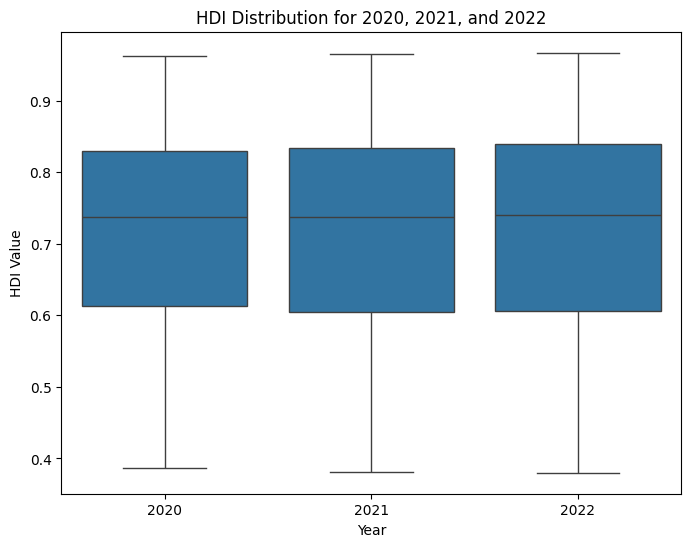

In [18]:
hdi_box_df = hdi_data[hdi_data['year'].isin([2020, 2021, 2022])].copy()

hdi_box_df = hdi_box_df.replace("–", np.nan)
hdi_box_df['hdi'] = pd.to_numeric(hdi_box_df['hdi'], errors='coerce')
hdi_box_df.dropna(subset=['hdi', 'year'], inplace=True)

plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='hdi', data=hdi_box_df)
plt.xlabel("Year")
plt.ylabel("HDI Value")
plt.title("HDI Distribution for 2020, 2021, and 2022")
plt.show()


The box plot shows a slight increase in the median HDI between 2020 and 2022. Global inequality levels appear to be stable, as evidenced by the HDI values' overall spread remaining consistent over the course of the three years. Every year, a few low-HDI outliers representing the least developed nations remain. Highly developed nations continue to be high because the upper range exhibits little variation.

*Scatter Plot: HDI vs. GNI per Capita*

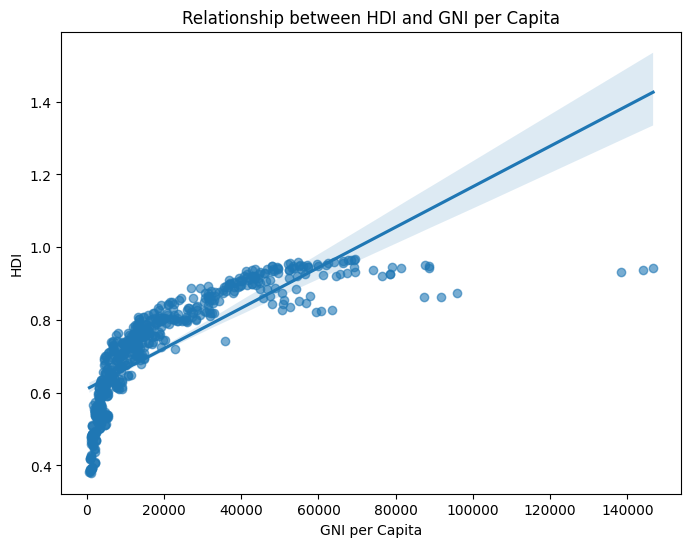

In [19]:
if 'gross_inc_percap' in hdi_data.columns:
    scatter_df = hdi_data[hdi_data['year'].isin([2020, 2021, 2022])].copy()
    scatter_df = scatter_df.replace("–", np.nan)

    scatter_df['hdi'] = pd.to_numeric(scatter_df['hdi'], errors='coerce')
    scatter_df['gross_inc_percap'] = pd.to_numeric(
        scatter_df['gross_inc_percap'], errors='coerce'
    )

    scatter_df.dropna(subset=['hdi', 'gross_inc_percap'], inplace=True)

    plt.figure(figsize=(8, 6))
    sns.regplot(
        x='gross_inc_percap',
        y='hdi',
        data=scatter_df,
        scatter_kws={'alpha': 0.6}
    )
    plt.xlabel("GNI per Capita")
    plt.ylabel("HDI")
    plt.title("Relationship between HDI and GNI per Capita")
    plt.show()
else:
    print("GNI per Capita variable not available in the dataset.")


The scatter plot indicates a robust positive correlation between GNI per capita and HDI, indicating that nations with higher income levels typically attain greater levels of human development. The HDI flattens at higher income levels and rises quickly at lower income levels, indicating a nonlinear pattern. There are a few obvious anomalies, such as nations with high income but comparatively lower HDI or low income but moderate HDI, suggesting that development is not entirely determined by income.

# 4. Short Analysis Questions:

 Q1.Which countries show the greatest improvement in HDI from 2020 to 2022?

Ans. Andorra shows one of the most notable improvement , it went from 0.843 hdi in 2020 to 0.884 by 2022. On second place Alegria also saw a improvement from 0.730 in 2020 to 0.745 in 2022.

Q2.Did any countries experience a decline in HDI? Provide possible reasons.

Ans. Yes Afghanistan saw a significant decline , with its HDI dropiing form 0.488 in 2020 to 0.462 in 2022. The decline is linked to education and health aspect. Egypt also saw a marginal decline from 0.729 in 2020 to 0.728 in 2022 , the possible reason for such decline can blamed to covid and political instality which affected GNI.

Q3.Which region has the highest and lowest average HDI across these three years?

Ans.Europe and Central Asia typically has the highest avg HDI and Sub-Saharan Afican region holds lowest average HDI.

Q4.Discuss how global events (e.g., the COVID-19 pandemic) may have affected HDI trends during
this period.

Ans. Global events like COVID-19 had severe impact in three aspects of HDI, Health, Education and Economy.
The pandemic reduced the earning as the whole world went into lockdown. Education institutes were shut down and virus claimed life of millions of people.

*4* Problem 2
# Advanced HDI Exploration

Task 1. Create South Asia Subset

In [20]:
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

hdi_south_asia = hdi_data[hdi_data['country'].isin(south_asia_countries)].copy()

hdi_south_asia.to_csv("HDI_SouthAsia.csv", index=False)

print("South Asia subset saved as 'HDI_SouthAsia.csv'")


South Asia subset saved as 'HDI_SouthAsia.csv'


Task-2. Composite Development Score

In [21]:
sa_latest = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

sa_latest = sa_latest.replace("–", np.nan)

sa_latest['life_expectancy'] = pd.to_numeric(
    sa_latest['life_expectancy'], errors='coerce'
)
sa_latest['gross_inc_percap'] = pd.to_numeric(
    sa_latest['gross_inc_percap'], errors='coerce'
)
sa_latest['hdi'] = pd.to_numeric(
    sa_latest['hdi'], errors='coerce'
)

sa_latest.dropna(
    subset=['life_expectancy', 'gross_inc_percap', 'hdi'],
    inplace=True
)

sa_latest['Composite Score'] = (
    0.30 * sa_latest['life_expectancy'] +
    0.30 * sa_latest['gross_inc_percap']
)


In [22]:
composite_rank = sa_latest.sort_values(
    by='Composite Score', ascending=False
)

print(composite_rank[['country', 'Composite Score', 'hdi']])


          country  Composite Score    hdi
3530     Maldives      5678.289357  0.762
5477    Sri Lanka      3592.832541  0.780
659        Bhutan      3209.130864  0.681
2573        India      2105.481239  0.644
461    Bangladesh      1975.446053  0.670
4388     Pakistan      1632.210427  0.540
4091        Nepal      1228.811605  0.601
32    Afghanistan       419.425420  0.462


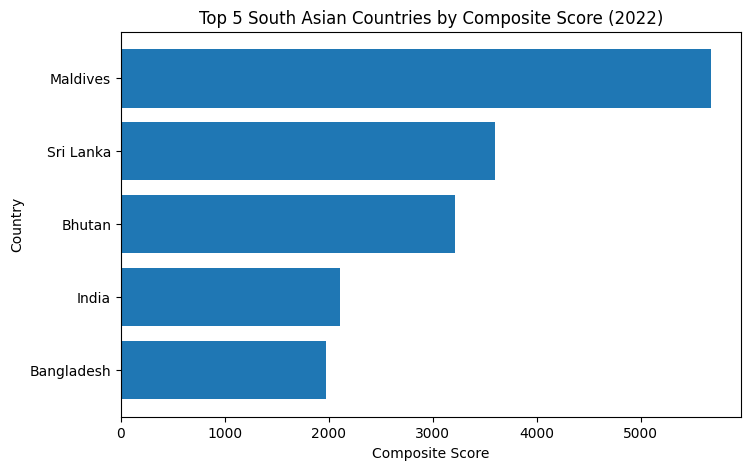

In [23]:
top5_composite = composite_rank.head(5)

plt.figure(figsize=(8, 5))
plt.barh(
    top5_composite['country'],
    top5_composite['Composite Score']
)
plt.xlabel("Composite Score")
plt.ylabel("Country")
plt.title("Top 5 South Asian Countries by Composite Score (2022)")
plt.gca().invert_yaxis()
plt.show()


Life expectancy and GNI per capita have a significant impact on overall human development, as evidenced by the Composite Development Score rankings' general similarity to the HDI rankings. Because of their higher income levels and better health outcomes, nations like Sri Lanka and the Maldives score highly on both metrics.

Nonetheless, minor variations are noted for certain nations. A nation with comparatively higher income but lower education indicators, for instance, might score higher on the Composite Score but marginally lower on the HDI because the HDI also takes into account education factors that are not included in the Composite Score calculation. In a similar vein, nations with stronger educational systems but moderate incomes might do better on the HDI than the Composite Score.

These variations show that education is a key factor in determining HDI rankings, making it a more comprehensive indicator than the simplified Composite Score, even though income and health are significant drivers of development.

Task-3. Outiner Detection

In [24]:
sa_2022 = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

sa_2022 = sa_2022.replace("–", np.nan)

sa_2022['hdi'] = pd.to_numeric(
sa_2022['hdi'], errors='coerce'
)
sa_2022['gross_inc_percap'] = pd.to_numeric(
sa_2022['gross_inc_percap'], errors='coerce'
)

sa_2022.dropna(subset=['hdi', 'gross_inc_percap'], inplace=True)

Q1_hdi = sa_2022['hdi'].quantile(0.25)
Q3_hdi = sa_2022['hdi'].quantile(0.75)
IQR_hdi = Q3_hdi - Q1_hdi

Q1_gni = sa_2022['gross_inc_percap'].quantile(0.25)
Q3_gni = sa_2022['gross_inc_percap'].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni

outliers_sa = sa_2022[
    (sa_2022['hdi'] < Q1_hdi - 1.5 * IQR_hdi) |
    (sa_2022['hdi'] > Q3_hdi + 1.5 * IQR_hdi) |
    (sa_2022['gross_inc_percap'] < Q1_gni - 1.5 * IQR_gni) |
    (sa_2022['gross_inc_percap'] > Q3_gni + 1.5 * IQR_gni)
]

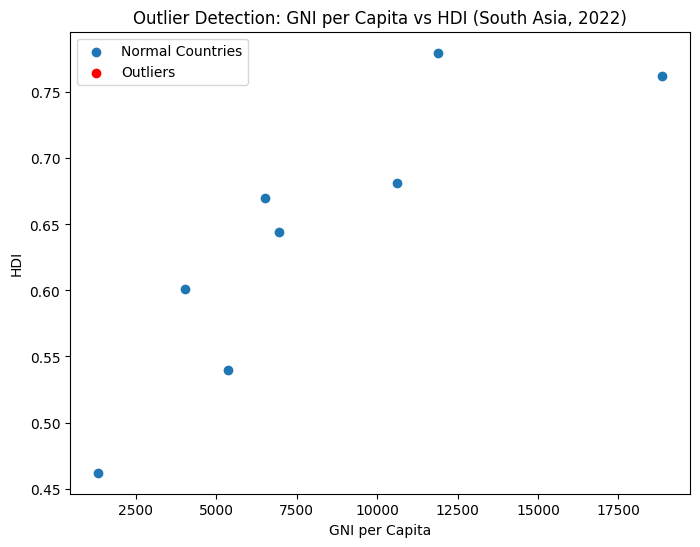

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    sa_2022['gross_inc_percap'],
    sa_2022['hdi'],
    label='Normal Countries'
)

plt.scatter(
    outliers_sa['gross_inc_percap'],
    outliers_sa['hdi'],
    color='red',
    label='Outliers'
)

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("Outlier Detection: GNI per Capita vs HDI (South Asia, 2022)")
plt.legend()
plt.show()


The countries with development patterns that deviate significantly from the regional norm are represented by the outliers found using the 1.5 × IQR rule. Due to their extremely low income and low HDI, some people appear to be low-end outliers, reflecting issues like unstable economies and inadequate healthcare systems. Others stand out as high-end anomalies due to their exceptionally high GNI per capita when compared to nearby nations. These examples show that human development outcomes are not entirely determined by income alone.

4. Exploring Metric Relationships:


In [26]:
metric_df = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

metric_df = metric_df.replace("–", np.nan)

metric_df['hdi'] = pd.to_numeric(metric_df['hdi'], errors='coerce')
metric_df['gender_development'] = pd.to_numeric(
    metric_df['gender_development'], errors='coerce'
)
metric_df['life_expectancy'] = pd.to_numeric(
    metric_df['life_expectancy'], errors='coerce'
)

metric_df.dropna(
    subset=['hdi', 'gender_development', 'life_expectancy'],
    inplace=True
)

In [27]:
corr_gender_hdi = metric_df['gender_development'].corr(metric_df['hdi'])
corr_life_hdi = metric_df['life_expectancy'].corr(metric_df['hdi'])

print("Pearson Correlation (Gender Development vs HDI):", corr_gender_hdi)
print("Pearson Correlation (Life Expectancy vs HDI):", corr_life_hdi)


Pearson Correlation (Gender Development vs HDI): 0.884759535448765
Pearson Correlation (Life Expectancy vs HDI): 0.9281974040239385


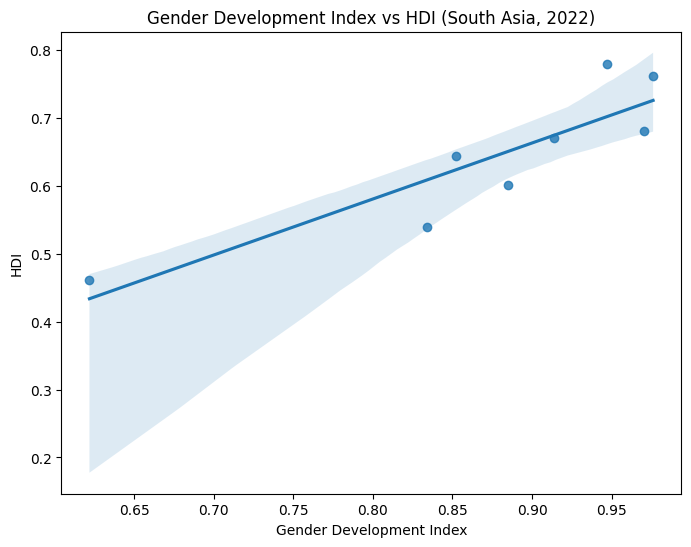

In [28]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='gender_development',
    y='hdi',
    data=metric_df
)
plt.xlabel("Gender Development Index")
plt.ylabel("HDI")
plt.title("Gender Development Index vs HDI (South Asia, 2022)")
plt.show()


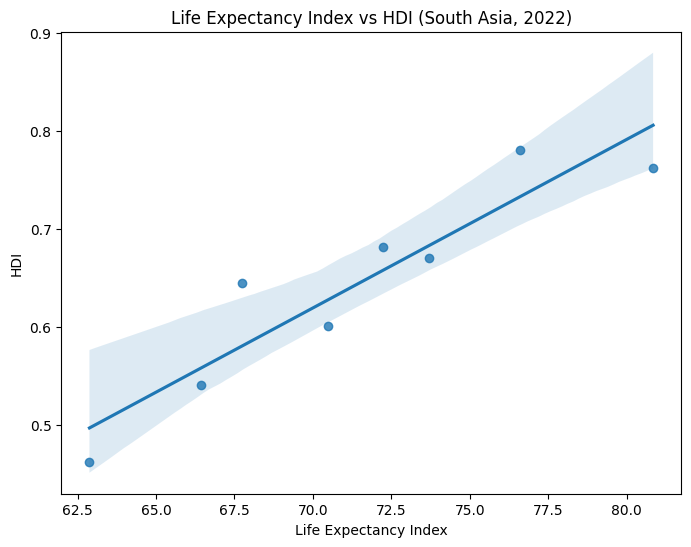

In [29]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='life_expectancy',
    y='hdi',
    data=metric_df
)
plt.xlabel("Life Expectancy Index")
plt.ylabel("HDI")
plt.title("Life Expectancy Index vs HDI (South Asia, 2022)")
plt.show()


Life expectancy has the strongest positive correlation with HDI, according to the analysis, suggesting that nations with better health outcomes regularly attain higher levels of human development. The gender development index, on the other hand, shows a weaker but still positive correlation with the HDI, indicating greater variation between nations. This pattern is supported by the scatter plots, which show that life expectancy data points form a tighter linear trend than gender development. This suggests that healthcare advancements have a greater direct impact on HDI growth than factors solely related to gender.

Task-5. Gap Analysis

In [30]:
gap_df = hdi_south_asia[hdi_south_asia['year'] == 2022].copy()

gap_df = gap_df.replace("–", np.nan)

gap_df['gross_inc_percap'] = pd.to_numeric(
    gap_df['gross_inc_percap'], errors='coerce'
)
gap_df['hdi'] = pd.to_numeric(
    gap_df['hdi'], errors='coerce'
)

gap_df.dropna(subset=['gross_inc_percap', 'hdi'], inplace=True)

gap_df['GNI_HDI_Gap'] = gap_df['gross_inc_percap'] - gap_df['hdi']


In [31]:
gap_desc = gap_df.sort_values(by='GNI_HDI_Gap', ascending=False)
print(gap_desc[['country', 'GNI_HDI_Gap']])


          country   GNI_HDI_Gap
3530     Maldives  18846.030190
5477    Sri Lanka  11898.718470
659        Bhutan  10624.192880
2573        India   6949.882798
461    Bangladesh   6510.452178
4388     Pakistan   5373.730423
4091        Nepal   4024.953685
32    Afghanistan   1334.743733


In [32]:
gap_asc = gap_df.sort_values(by='GNI_HDI_Gap', ascending=True)
print(gap_asc[['country', 'GNI_HDI_Gap']])


          country   GNI_HDI_Gap
32    Afghanistan   1334.743733
4091        Nepal   4024.953685
4388     Pakistan   5373.730423
461    Bangladesh   6510.452178
2573        India   6949.882798
659        Bhutan  10624.192880
5477    Sri Lanka  11898.718470
3530     Maldives  18846.030190


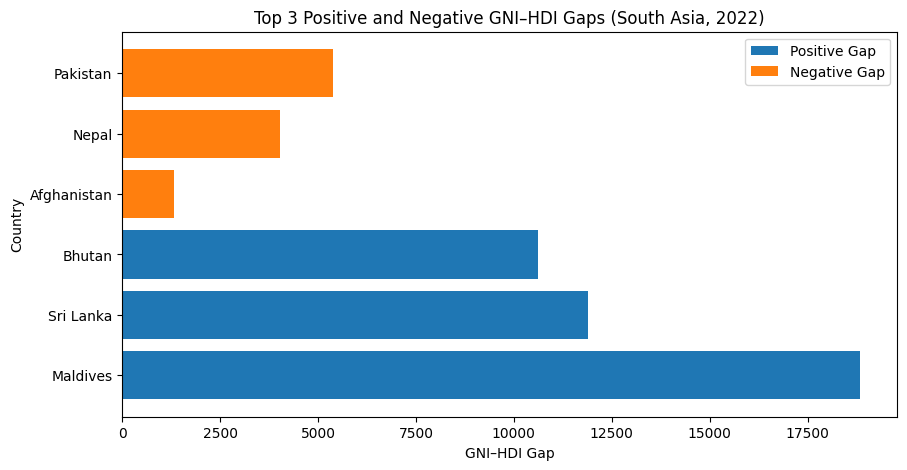

In [33]:
top_positive = gap_desc.head(3)
top_negative = gap_asc.head(3)

plt.figure(figsize=(10, 5))

plt.barh(
    top_positive['country'],
    top_positive['GNI_HDI_Gap'],
    label='Positive Gap'
)

plt.barh(
    top_negative['country'],
    top_negative['GNI_HDI_Gap'],
    label='Negative Gap'
)

plt.xlabel("GNI–HDI Gap")
plt.ylabel("Country")
plt.title("Top 3 Positive and Negative GNI–HDI Gaps (South Asia, 2022)")
plt.legend()
plt.show()


Disparities between economic income and real human development outcomes are highlighted by the GNI–HDI gap. Large positive gaps are found in nations with comparatively high income levels but lower HDI values, suggesting that improvements in health, education, and living standards are not entirely correlated with wealth. On the other hand, despite having lower incomes, nations with negative or tiny gaps have relatively higher HDI, indicating efficient use of scarce resources. These findings highlight the need for balanced investments in social sectors rather than just economic growth for sustainable development.

5 Problem 3
# Comparative Regional Analysis: South Asia vs Middle East


1. Create Middle East Subset:

In [34]:
problem1b_df = pd.read_csv("HDI_Trend_2020_2022.csv")

south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east_countries = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]

south_asia_2020_2022 = problem1b_df[
    problem1b_df['country'].isin(south_asia_countries)
].copy()

middle_east_2020_2022 = problem1b_df[
    problem1b_df['country'].isin(middle_east_countries)
].copy()

south_asia_2020_2022.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
middle_east_2020_2022.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

print("Files saved: HDI_SouthAsia_2020_2022.csv and HDI_MiddleEast_2020_2022.csv")

Files saved: HDI_SouthAsia_2020_2022.csv and HDI_MiddleEast_2020_2022.csv


2. Descriptive Statistics:

In [35]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

sa_df['hdi'] = pd.to_numeric(sa_df['hdi'], errors='coerce')
me_df['hdi'] = pd.to_numeric(me_df['hdi'], errors='coerce')

sa_mean = sa_df['hdi'].mean()
sa_std = sa_df['hdi'].std()

me_mean = me_df['hdi'].mean()
me_std = me_df['hdi'].std()

print("South Asia HDI Mean:", sa_mean)
print("South Asia HDI Std Dev:", sa_std)

print("Middle East HDI Mean:", me_mean)
print("Middle East HDI Std Dev:", me_std)


South Asia HDI Mean: 0.6395833333333333
South Asia HDI Std Dev: 0.09827331747496995
Middle East HDI Mean: 0.7889090909090909
Middle East HDI Std Dev: 0.14129476362297624


3. Top and Bottom Performers:


In [36]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

sa_df['hdi'] = pd.to_numeric(sa_df['hdi'], errors='coerce')
me_df['hdi'] = pd.to_numeric(me_df['hdi'], errors='coerce')

sa_avg = sa_df.groupby('country')['hdi'].mean().reset_index()
me_avg = me_df.groupby('country')['hdi'].mean().reset_index()

sa_top3 = sa_avg.sort_values(by='hdi', ascending=False).head(3)
sa_bottom3 = sa_avg.sort_values(by='hdi', ascending=True).head(3)

me_top3 = me_avg.sort_values(by='hdi', ascending=False).head(3)
me_bottom3 = me_avg.sort_values(by='hdi', ascending=True).head(3)


In [37]:
compare_df = pd.concat([
    sa_top3.assign(region='South Asia', type='Top'),
    sa_bottom3.assign(region='South Asia', type='Bottom'),
    me_top3.assign(region='Middle East', type='Top'),
    me_bottom3.assign(region='Middle East', type='Bottom')
])


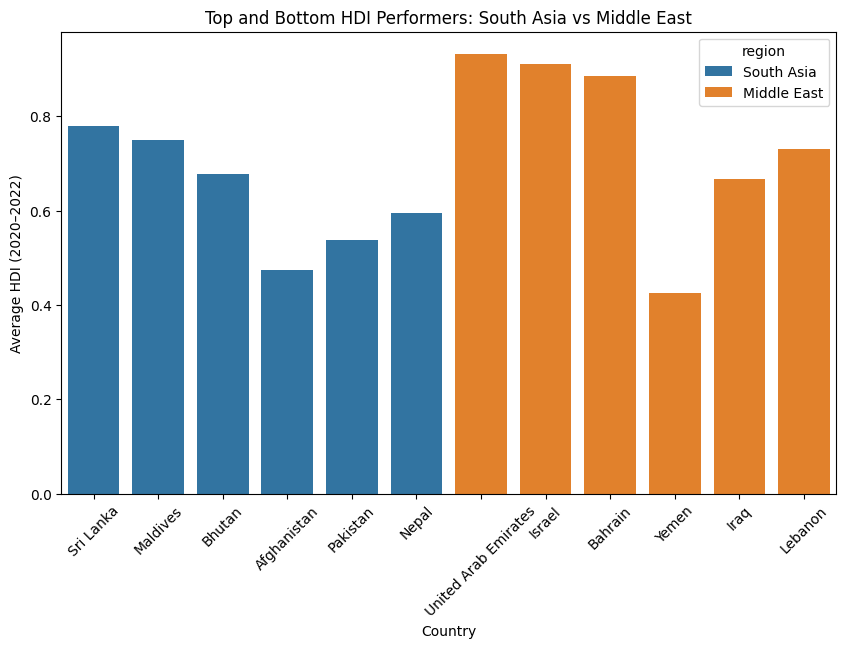

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=compare_df,
    x='country',
    y='hdi',
    hue='region'
)
plt.xlabel("Country")
plt.ylabel("Average HDI (2020–2022)")
plt.title("Top and Bottom HDI Performers: South Asia vs Middle East")
plt.xticks(rotation=45)
plt.show()


Task-4. Metric Comparisons

In [39]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']

for col in metrics:
    sa_df[col] = pd.to_numeric(sa_df[col], errors='coerce')
    me_df[col] = pd.to_numeric(me_df[col], errors='coerce')

sa_mean_metrics = sa_df[metrics].mean().reset_index()
sa_mean_metrics['region'] = 'South Asia'

me_mean_metrics = me_df[metrics].mean().reset_index()
me_mean_metrics['region'] = 'Middle East'

metric_compare_df = pd.concat([sa_mean_metrics, me_mean_metrics])
metric_compare_df.columns = ['metric', 'value', 'region']


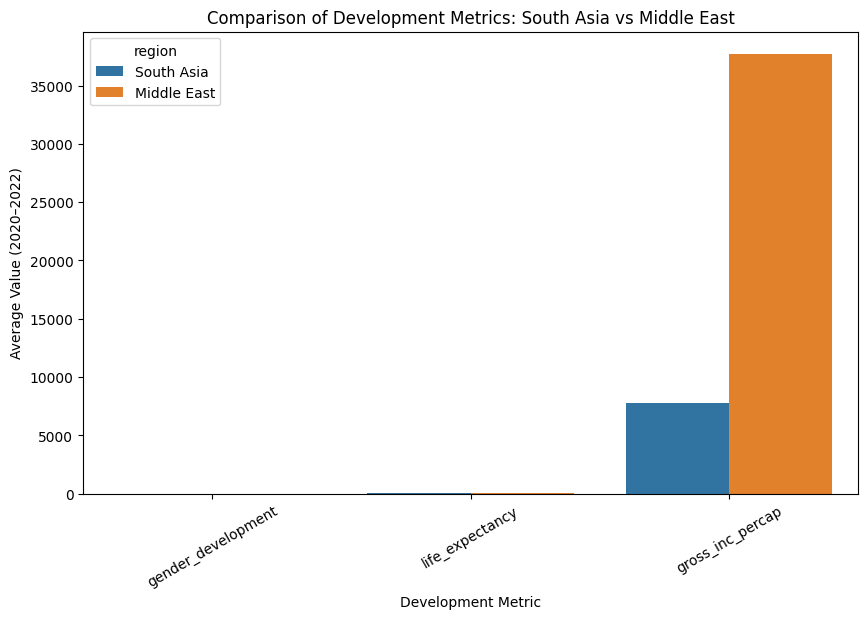

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=metric_compare_df,
    x='metric',
    y='value',
    hue='region'
)
plt.xlabel("Development Metric")
plt.ylabel("Average Value (2020–2022)")
plt.title("Comparison of Development Metrics: South Asia vs Middle East")
plt.xticks(rotation=30)
plt.show()


5. HDI Disparity:


In [41]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

sa_df['hdi'] = pd.to_numeric(sa_df['hdi'], errors='coerce')
me_df['hdi'] = pd.to_numeric(me_df['hdi'], errors='coerce')

sa_max = sa_df['hdi'].max()
sa_min = sa_df['hdi'].min()
sa_range = sa_max - sa_min

me_max = me_df['hdi'].max()
me_min = me_df['hdi'].min()
me_range = me_max - me_min

sa_cv = sa_df['hdi'].std() / sa_df['hdi'].mean()
me_cv = me_df['hdi'].std() / me_df['hdi'].mean()

print("South Asia HDI Range:", sa_range)
print("South Asia HDI CV:", sa_cv)

print("Middle East HDI Range:", me_range)
print("Middle East HDI CV:", me_cv)


South Asia HDI Range: 0.321
South Asia HDI CV: 0.1536520924690084
Middle East HDI Range: 0.5130000000000001
Middle East HDI CV: 0.17910145193048382


Task-6. Corelation Analysis

In [42]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

cols = ['hdi', 'gender_development', 'life_expectancy']

for c in cols:
    sa_df[c] = pd.to_numeric(sa_df[c], errors='coerce')
    me_df[c] = pd.to_numeric(me_df[c], errors='coerce')

sa_df.dropna(subset=cols, inplace=True)
me_df.dropna(subset=cols, inplace=True)


In [43]:
sa_corr_gender = sa_df['hdi'].corr(sa_df['gender_development'])
sa_corr_life = sa_df['hdi'].corr(sa_df['life_expectancy'])

me_corr_gender = me_df['hdi'].corr(me_df['gender_development'])
me_corr_life = me_df['hdi'].corr(me_df['life_expectancy'])

print("South Asia - HDI vs Gender Development:", sa_corr_gender)
print("South Asia - HDI vs Life Expectancy:", sa_corr_life)

print("Middle East - HDI vs Gender Development:", me_corr_gender)
print("Middle East - HDI vs Life Expectancy:", me_corr_life)


South Asia - HDI vs Gender Development: 0.8742177004831327
South Asia - HDI vs Life Expectancy: 0.9387641385416623
Middle East - HDI vs Gender Development: 0.9356697525724119
Middle East - HDI vs Life Expectancy: 0.9331227568940162


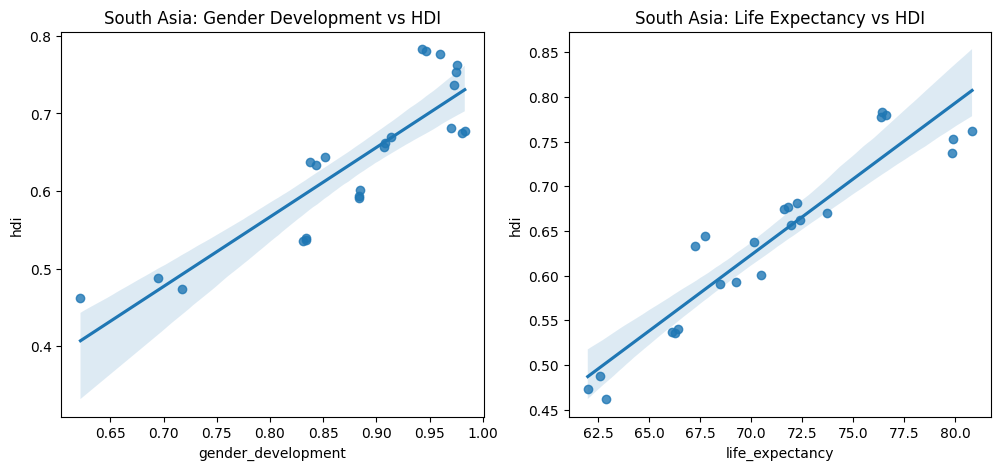

In [44]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x='gender_development', y='hdi', data=sa_df)
plt.title("South Asia: Gender Development vs HDI")

plt.subplot(1, 2, 2)
sns.regplot(x='life_expectancy', y='hdi', data=sa_df)
plt.title("South Asia: Life Expectancy vs HDI")

plt.show()


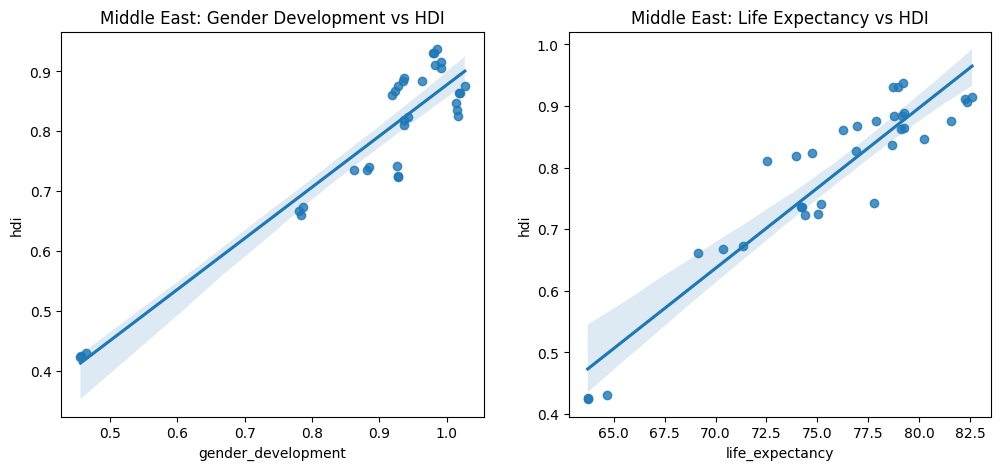

In [45]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x='gender_development', y='hdi', data=me_df)
plt.title("Middle East: Gender Development vs HDI")

plt.subplot(1, 2, 2)
sns.regplot(x='life_expectancy', y='hdi', data=me_df)
plt.title("Middle East: Life Expectancy vs HDI")

plt.show()


In both South Asia and the Middle East, the HDI has a strong positive correlation with life expectancy, demonstrating that improved health outcomes result in greater human development. Though more moderately, there is a positive correlation between the gender development index and the HDI. This suggests that of the two metrics, life expectancy has the biggest influence on HDI.

Task7. Outliner Detection

In [46]:
sa_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
me_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

for df in [sa_df, me_df]:
    df['hdi'] = pd.to_numeric(df['hdi'], errors='coerce')
    df['gross_inc_percap'] = pd.to_numeric(df['gross_inc_percap'], errors='coerce')
    df.dropna(subset=['hdi', 'gross_inc_percap'], inplace=True)

def detect_outliers(df):
    Q1_hdi, Q3_hdi = df['hdi'].quantile([0.25, 0.75])
    IQR_hdi = Q3_hdi - Q1_hdi

    Q1_gni, Q3_gni = df['gross_inc_percap'].quantile([0.25, 0.75])
    IQR_gni = Q3_gni - Q1_gni

    return df[
        (df['hdi'] < Q1_hdi - 1.5 * IQR_hdi) |
        (df['hdi'] > Q3_hdi + 1.5 * IQR_hdi) |
        (df['gross_inc_percap'] < Q1_gni - 1.5 * IQR_gni) |
        (df['gross_inc_percap'] > Q3_gni + 1.5 * IQR_gni)
    ]

sa_outliers = detect_outliers(sa_df)
me_outliers = detect_outliers(me_df)

print("South Asia Outliers:")
print(sa_outliers[['country', 'hdi', 'gross_inc_percap']])

print("\nMiddle East Outliers:")
print(me_outliers[['country', 'hdi', 'gross_inc_percap']])

South Asia Outliers:
Empty DataFrame
Columns: [country, hdi, gross_inc_percap]
Index: []

Middle East Outliers:
   country    hdi  gross_inc_percap
30   Yemen  0.430       1152.015672
31   Yemen  0.425       1112.162989
32   Yemen  0.424       1105.763435


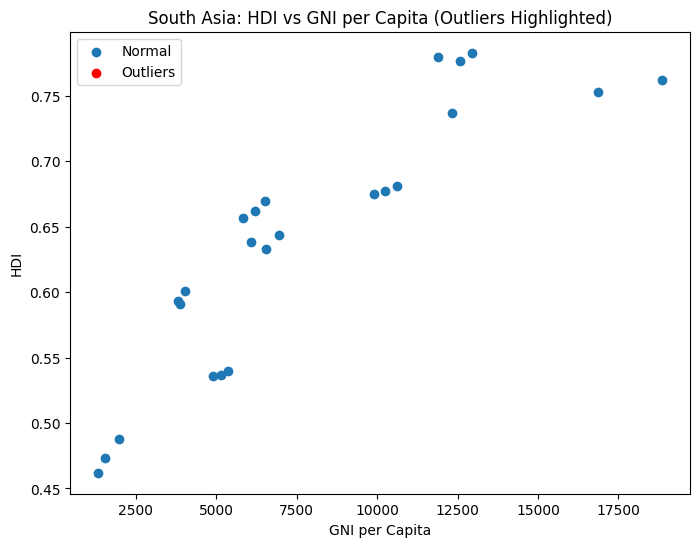

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(sa_df['gross_inc_percap'], sa_df['hdi'], label='Normal')
plt.scatter(sa_outliers['gross_inc_percap'], sa_outliers['hdi'], color='red', label='Outliers')
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("South Asia: HDI vs GNI per Capita (Outliers Highlighted)")
plt.legend()
plt.show()


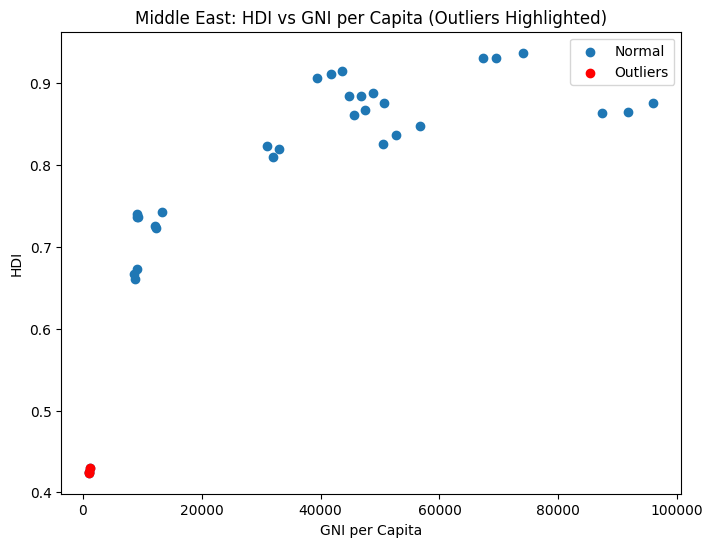

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(me_df['gross_inc_percap'], me_df['hdi'], label='Normal')
plt.scatter(me_outliers['gross_inc_percap'], me_outliers['hdi'], color='red', label='Outliers')
plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("Middle East: HDI vs GNI per Capita (Outliers Highlighted)")
plt.legend()
plt.show()


The countries whose income and HDI deviate significantly from regional trends are indicated by the outliers. Some people have high incomes but only moderate HDI, while others have very low values because of instability, poor health, or lack of education. This demonstrates that high levels of human development are not guaranteed by economic growth alone.